---
# CrewAI With Mem0

---
## Mem0 Provider
**Short-Term Memory** and **Entity Memory** both supports a tight integration with both `Mem0 OSS` and `Mem0 Client` as a provider. Here is how you can use `Mem0` as a provider.

### **Example-1** 👉 `Sample from Crew-AI Documentation`
```Python
from crewai.memory.short_term.short_term_memory import ShortTermMemory
from crewai.memory.entity_entity_memory import EntityMemory

mem0_oss_embedder_config = {
        "provider": "mem0",
        "config": {
            "user_id": "john",
            "local_mem0_config": {
                "vector_store": {"provider": "qdrant","config": {"host": "localhost", "port": 6333}},
                "llm": {"provider": "openai","config": {"api_key": "your-api-key", "model": "gpt-4"}},
                "embedder": {"provider": "openai","config": {"api_key": "your-api-key", "model": "text-embedding-3-small"}}
            },
            "infer": True # Optional defaults to True
        },
    }


mem0_client_embedder_config = {
        "provider": "mem0",
        "config": {
            "user_id": "john",
            "org_id": "my_org_id",        # Optional
            "project_id": "my_project_id", # Optional
            "api_key": "custom-api-key"    # Optional - overrides env var
            "run_id": "my_run_id",        # Optional - for short-term memory
            "includes": "include1",       # Optional 
            "excludes": "exclude1",       # Optional
            "infer": True                 # Optional defaults to True
            "custom_categories": new_categories  # Optional - custom categories for user memory
        },
    }


short_term_memory_mem0_oss = ShortTermMemory(embedder_config=mem0_oss_embedder_config) # Short Term Memory with Mem0 OSS
short_term_memory_mem0_client = ShortTermMemory(embedder_config=mem0_client_embedder_config) # Short Term Memory with Mem0 Client
entity_memory_mem0_oss = EntityMemory(embedder_config=mem0_oss_embedder_config) # Entity Memory with Mem0 OSS
entity_memory_mem0_client = EntityMemory(embedder_config=mem0_client_embedder_config) # Short Term Memory with Mem0 Client

crew = Crew(
    memory=True,
    short_term_memory=short_term_memory_mem0_oss, # or short_term_memory_mem0_client
    entity_memory=entity_memory_mem0_oss # or entity_memory_mem0_client
)
```
----

### **Example-2** 👉 `CrewAI_With_Mem0.py`
```Python
import os
from mem0 import MemoryClient
from crewai import Agent, Task, Crew, Process
from crewai_tools import SerperDevTool


# Initialize Mem0 client
client = MemoryClient()

def store_user_preferences(user_id: str, conversation: list):
    """Store user preferences from conversation history"""
    client.add(conversation, user_id=user_id)

# Example conversation storage
messages = [
    {
        "role": "user",
        "content": "Hi there! I'm planning a vacation and could use some advice.",
    },
    {
        "role": "assistant",
        "content": "Hello! I'd be happy to help with your vacation planning. What kind of destination do you prefer?",
    },
    {"role": "user", "content": "I am more of a beach person than a mountain person."},
    {
        "role": "assistant",
        "content": "That's interesting. Do you like hotels or airbnb?",
    },
    {"role": "user", "content": "I like airbnb more."},
]

store_user_preferences("crew_user_1", messages)


def create_travel_agent():
    """Create a travel planning agent with search capabilities"""
    search_tool = SerperDevTool()

    return Agent(
        role="Personalized Travel Planner Agent",
        goal="Plan personalized travel itineraries",
        backstory="""You are a seasoned travel planner, known for your meticulous attention to detail.""",
        allow_delegation=False,
        memory=True,
        tools=[search_tool],
    )

def create_planning_task(agent, destination: str):
    """Create a travel planning task"""
    return Task(
        description=f"""Find places to live, eat, and visit in {destination}.""",
        expected_output=f"A detailed list of places to live, eat, and visit in {destination}.",
        agent=agent,
    )

def setup_crew(agents: list, tasks: list):
    """Set up a crew with Mem0 memory integration"""
    return Crew(
        agents=agents,
        tasks=tasks,
        process=Process.sequential,
        memory=True,
        memory_config={
            "provider": "mem0",
            "config": {"user_id": "crew_user_1"},
        }
    )


def plan_trip(destination: str, user_id: str):
    # Create agent
    travel_agent = create_travel_agent()

    # Create task
    planning_task = create_planning_task(travel_agent, destination)

    # Setup crew
    crew = setup_crew([travel_agent], [planning_task])

    # Execute and return results
    return crew.kickoff()

# Example usage
if __name__ == "__main__":
    result = plan_trip("San Francisco", "crew_user_1")
    print(result)
```
---

### **Output**
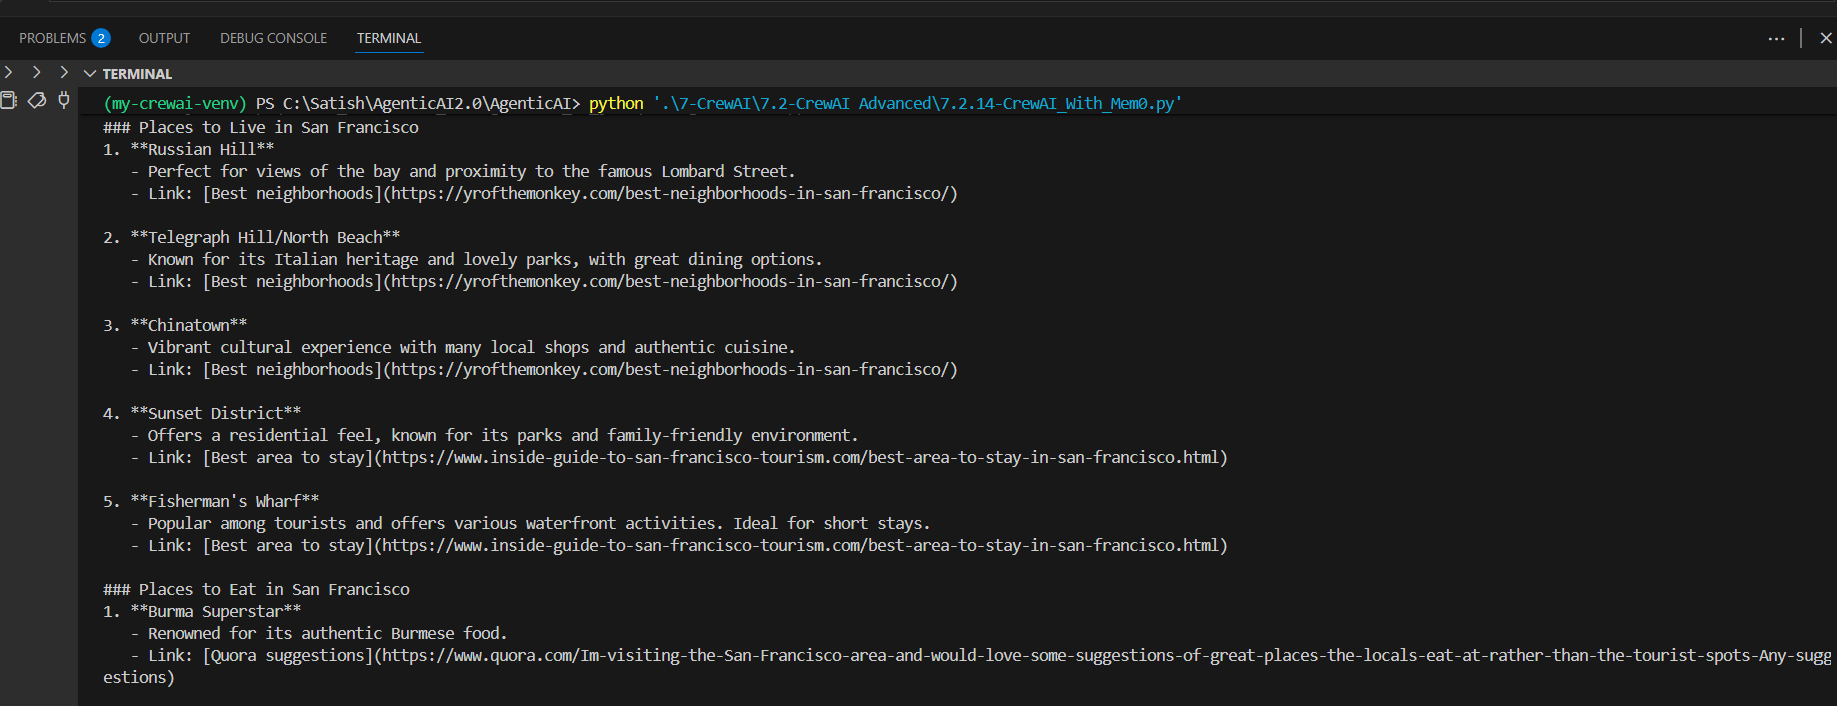 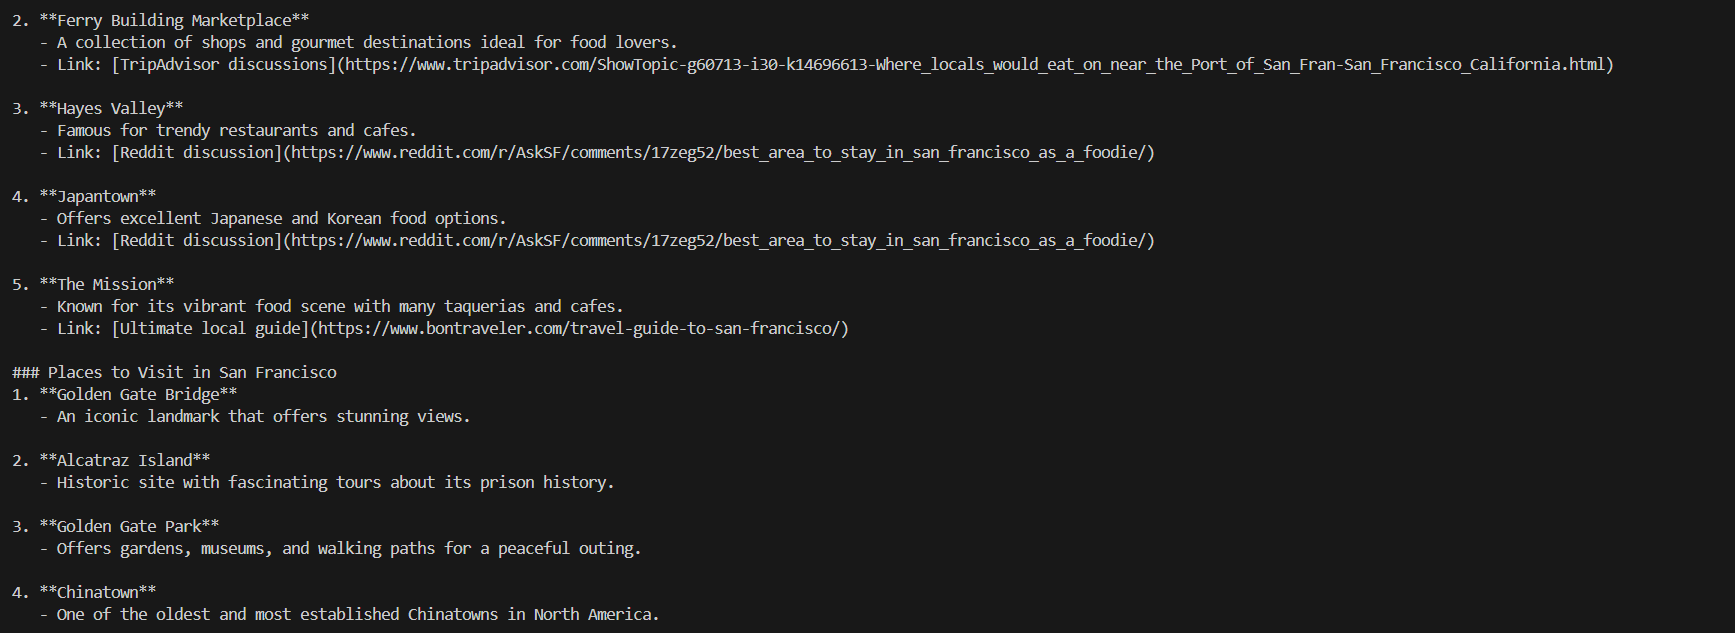 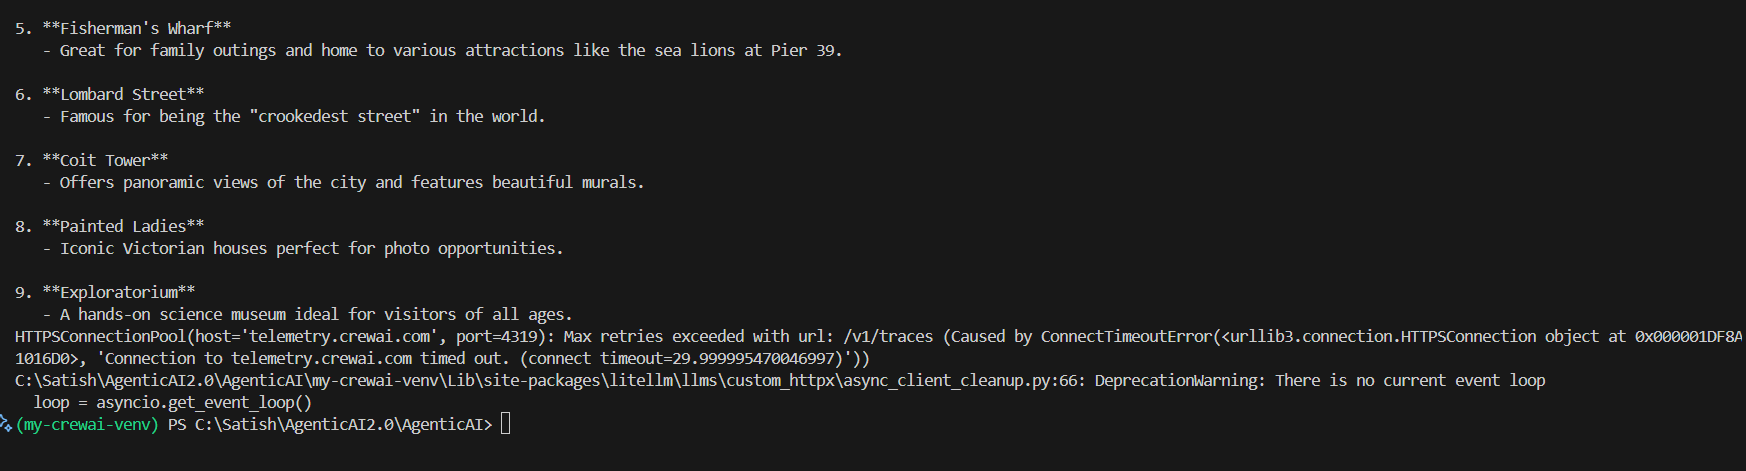 

--- 

#### **Mem0** 👉 **Dashboard** 👉 **Requests**
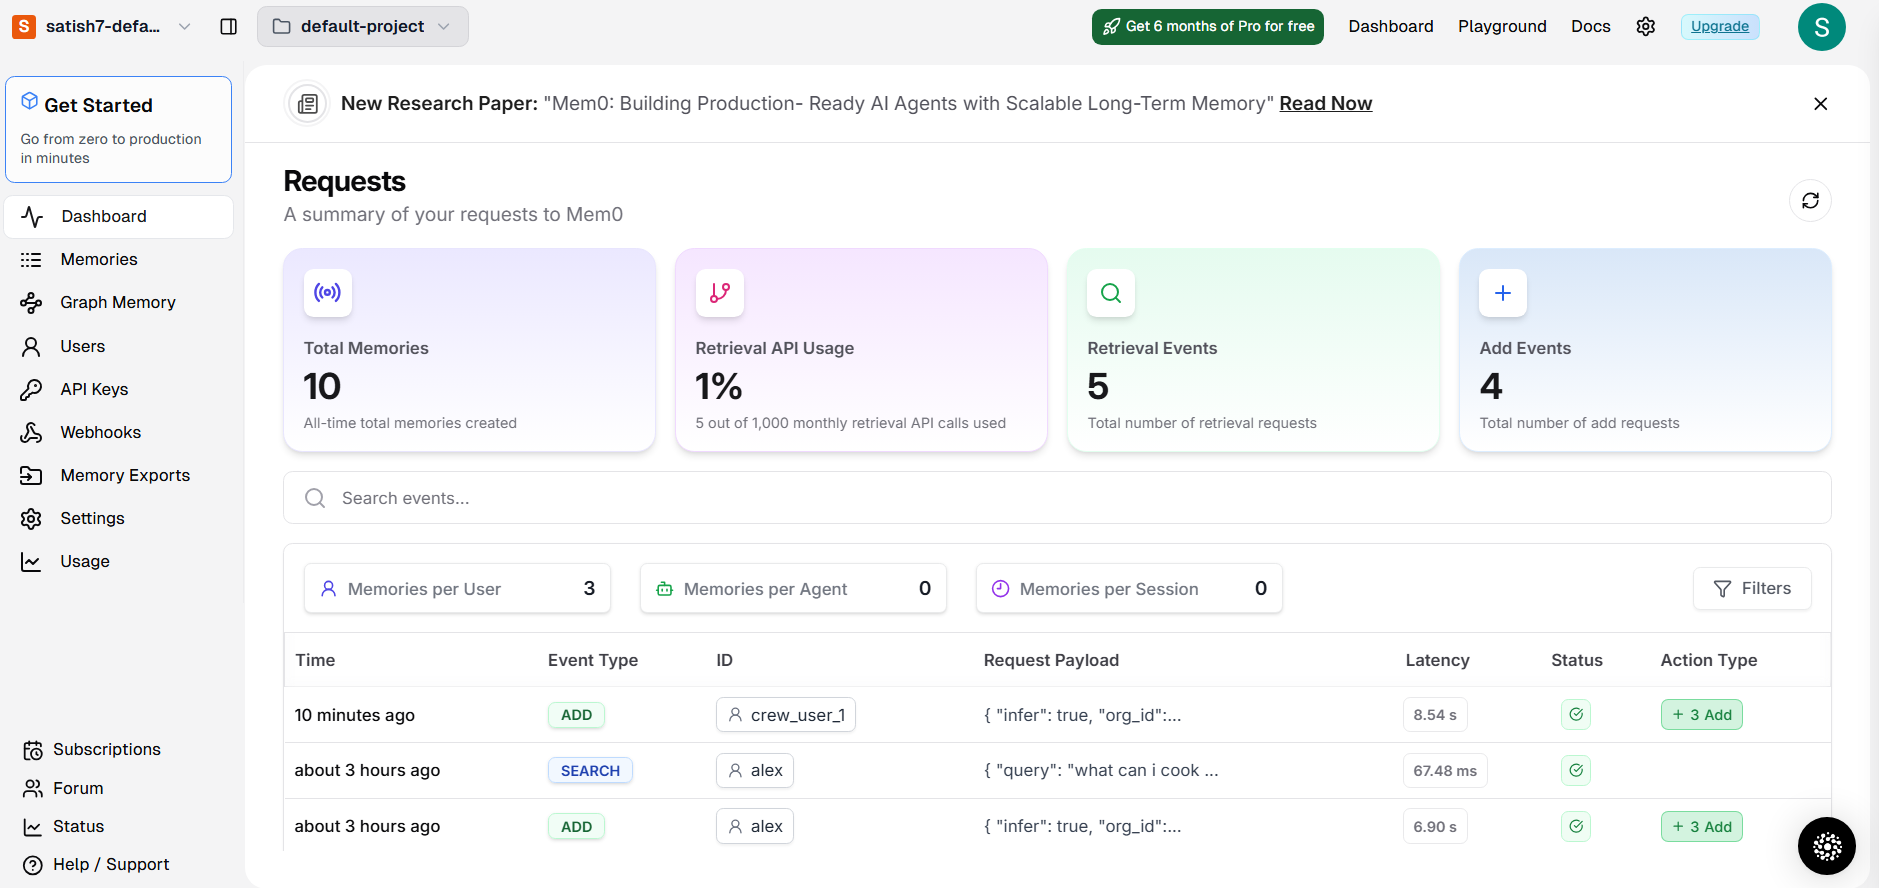 <br>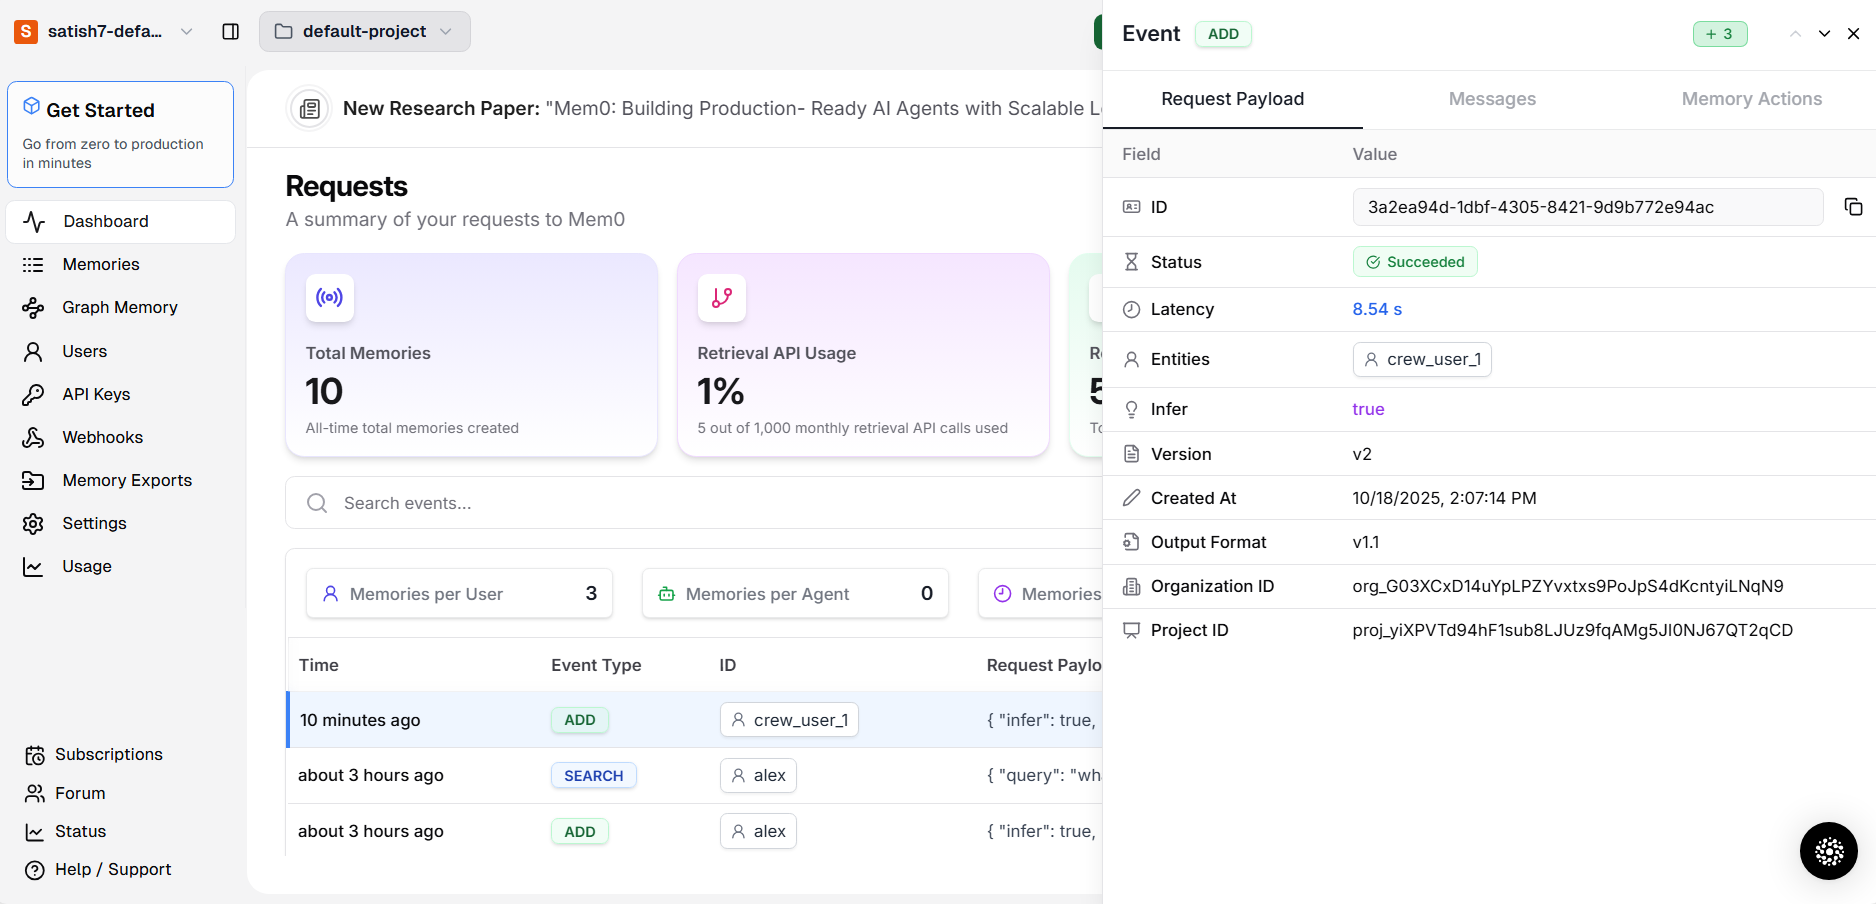 <br> 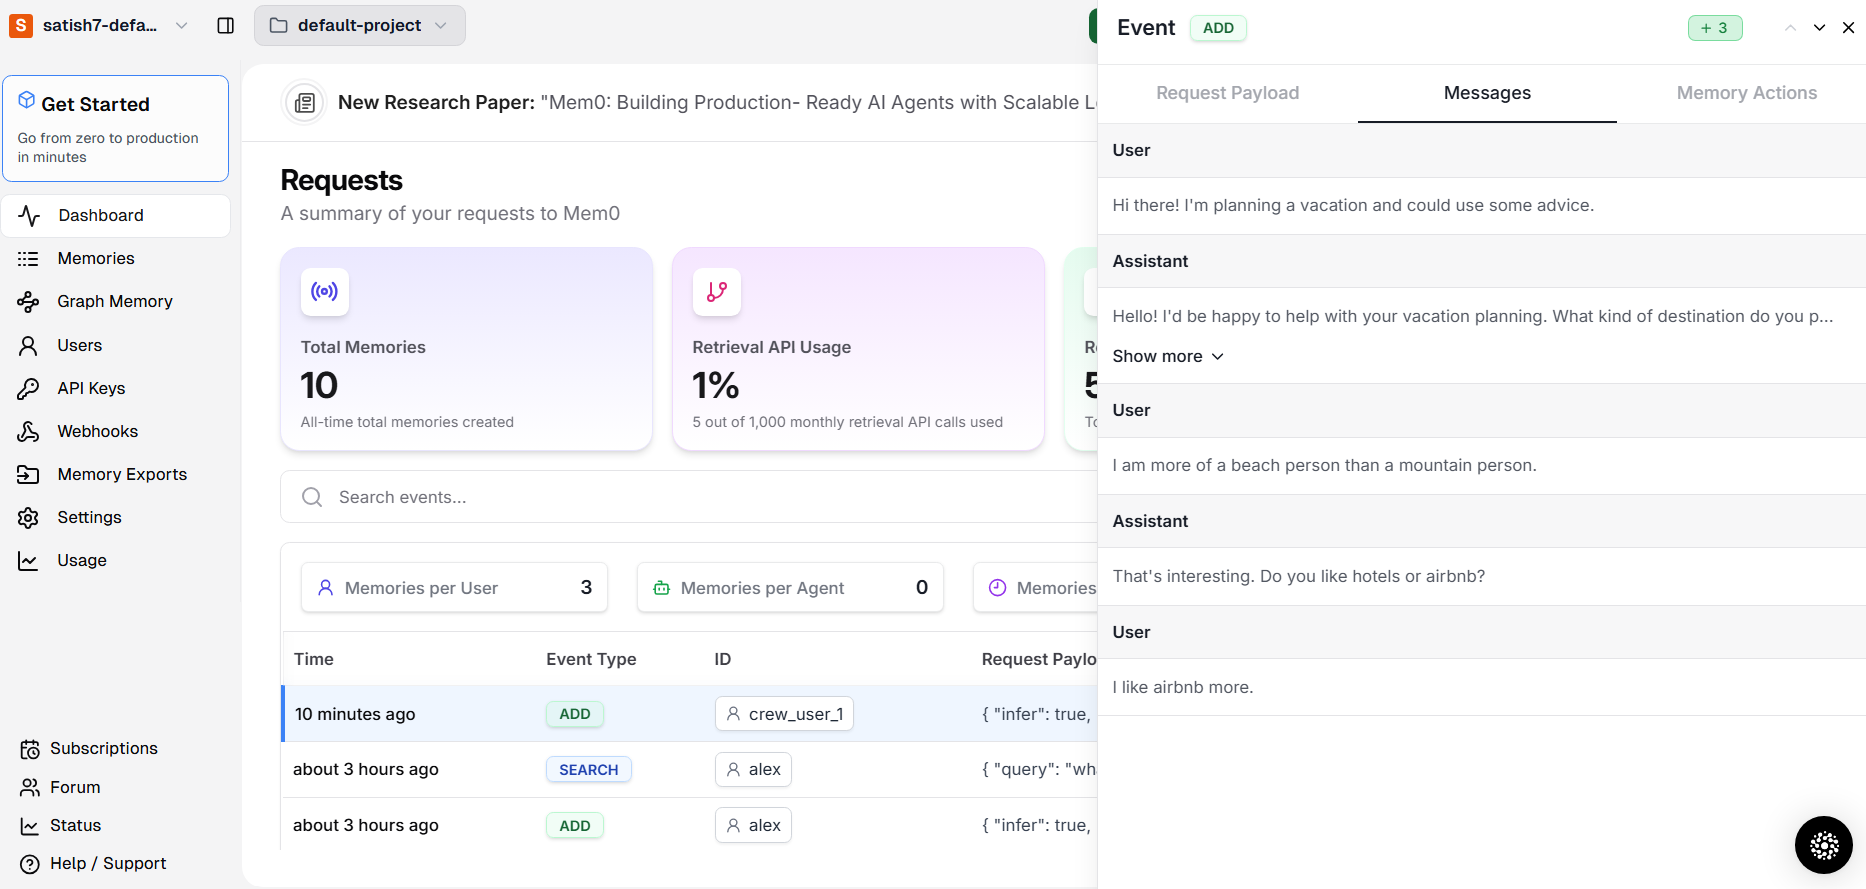 <br> 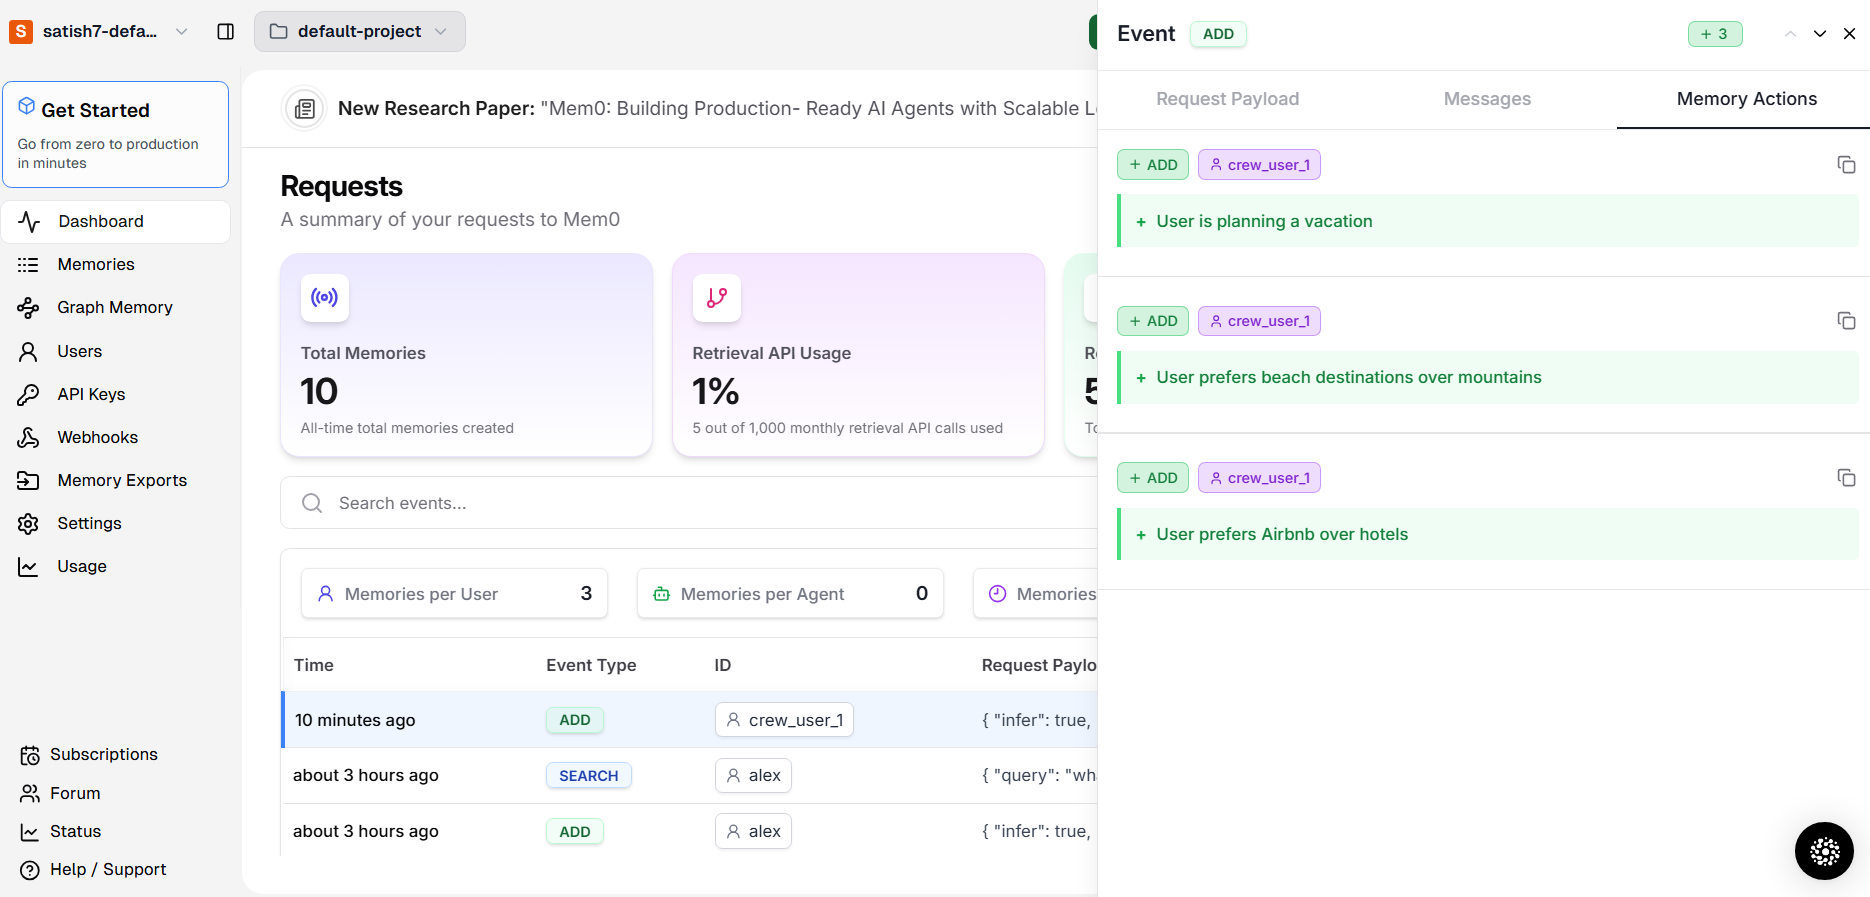 <br><br>

---

#### **Mem0** 👉 **Entities**
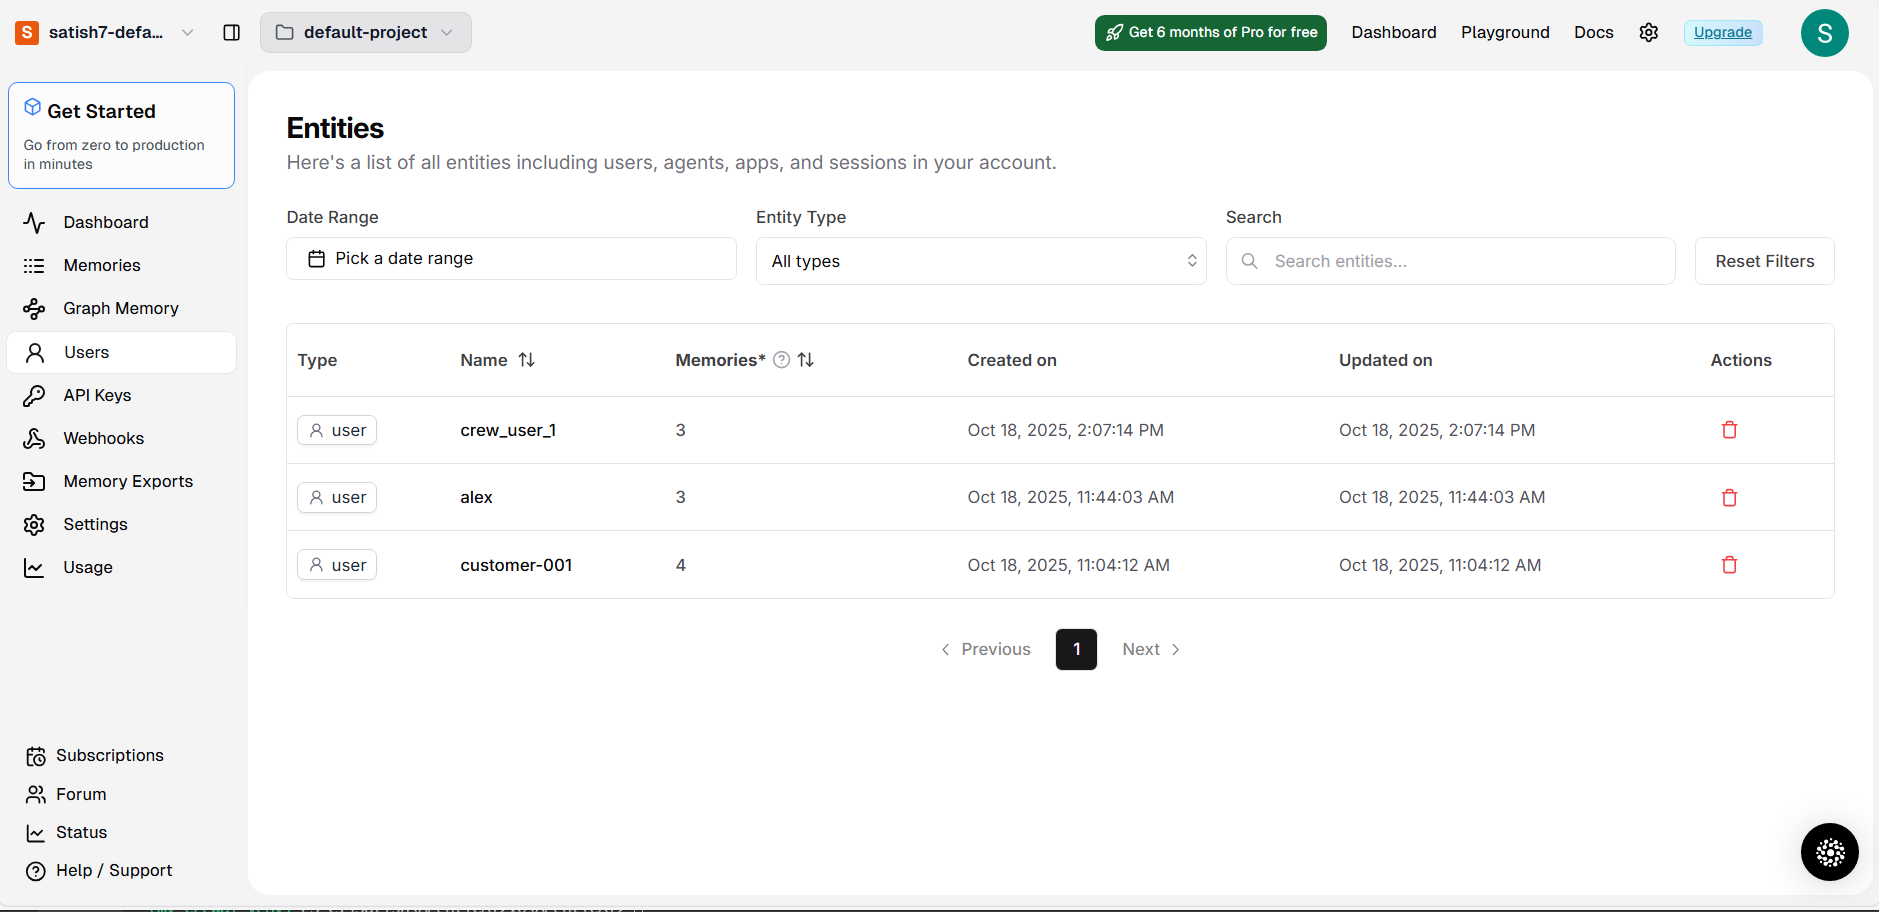 <br> 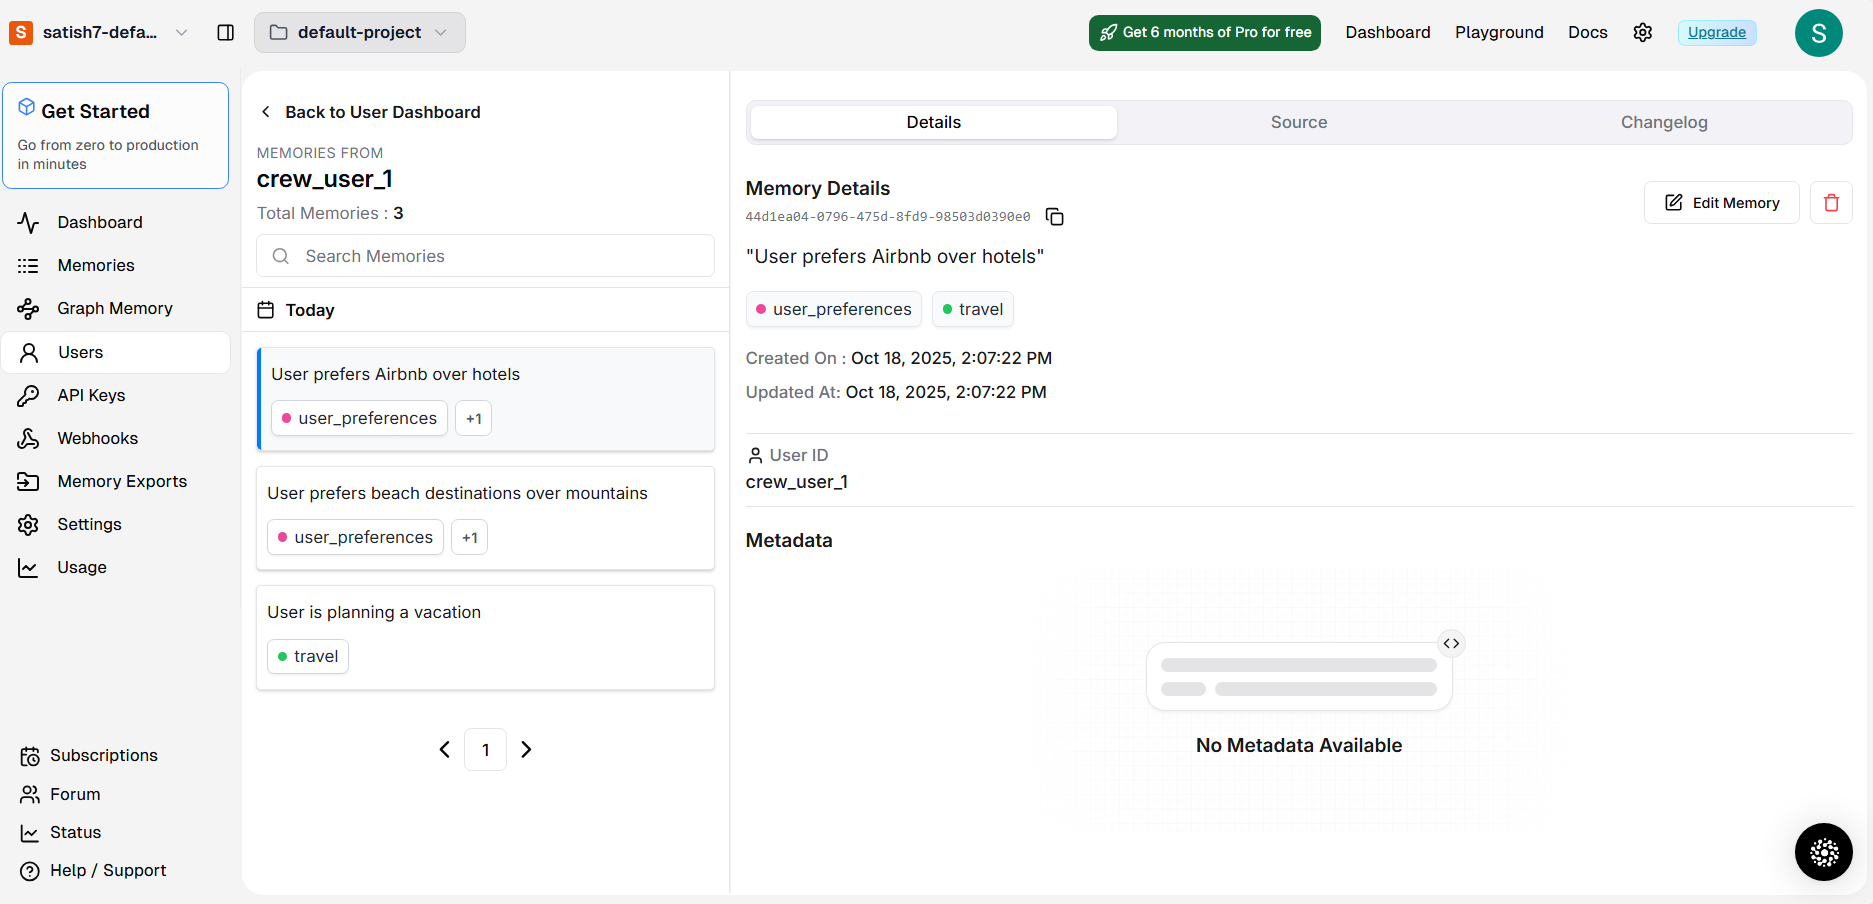 <br> 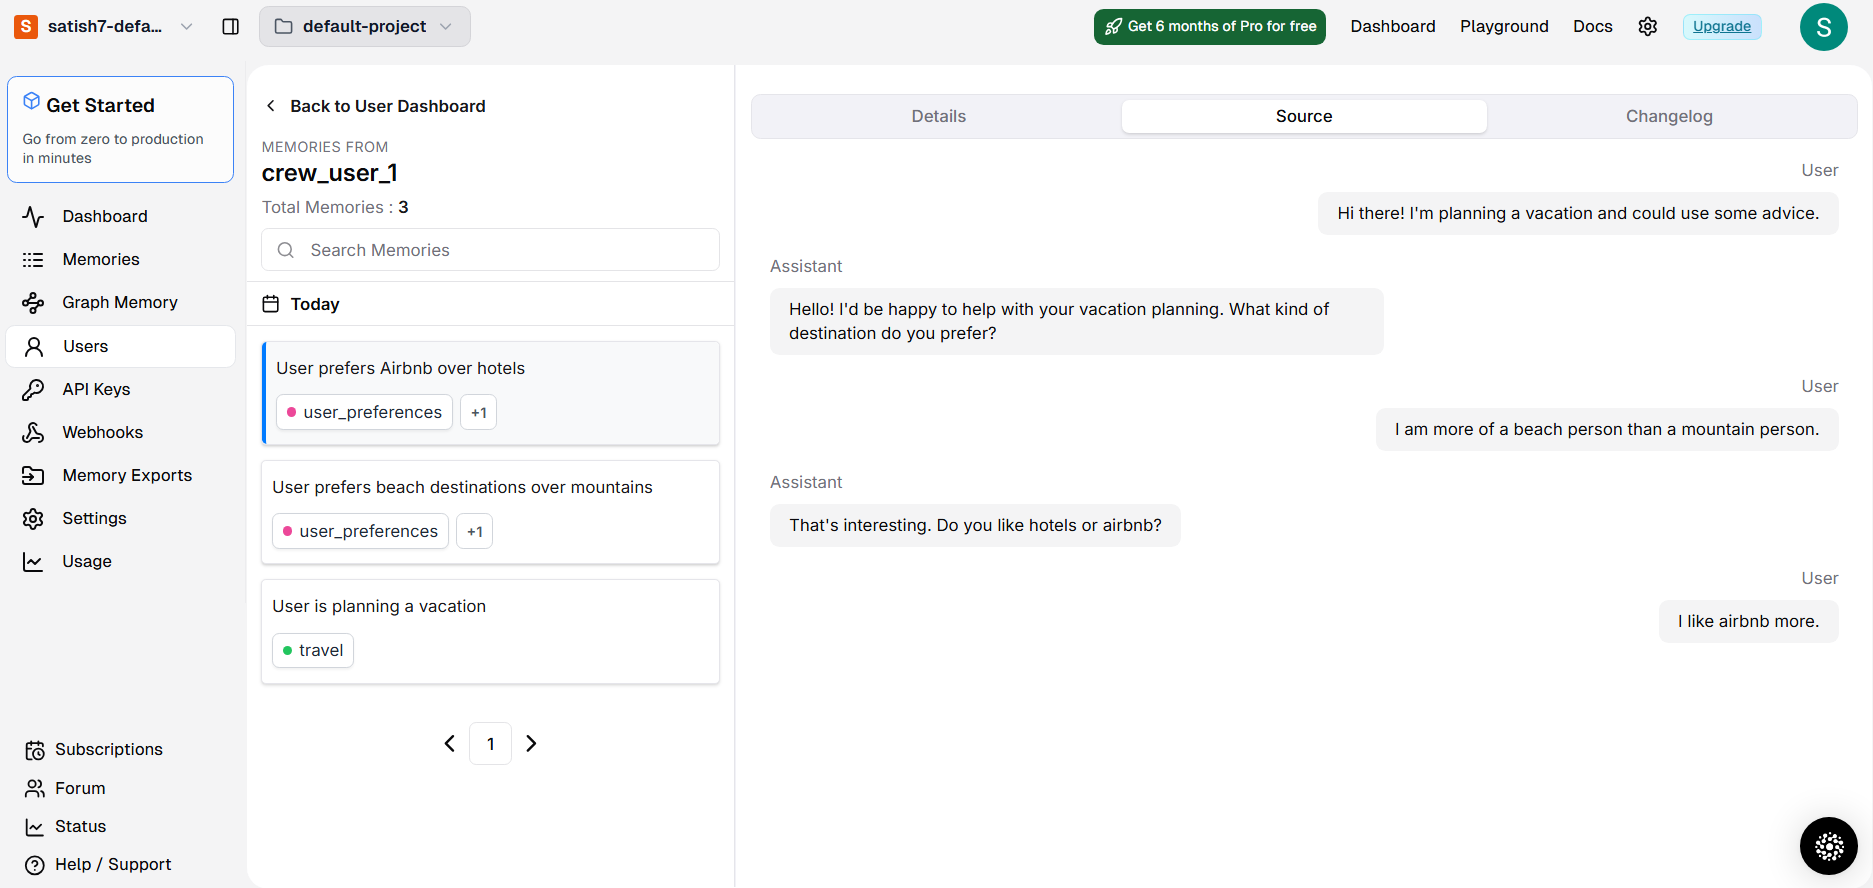 <br> 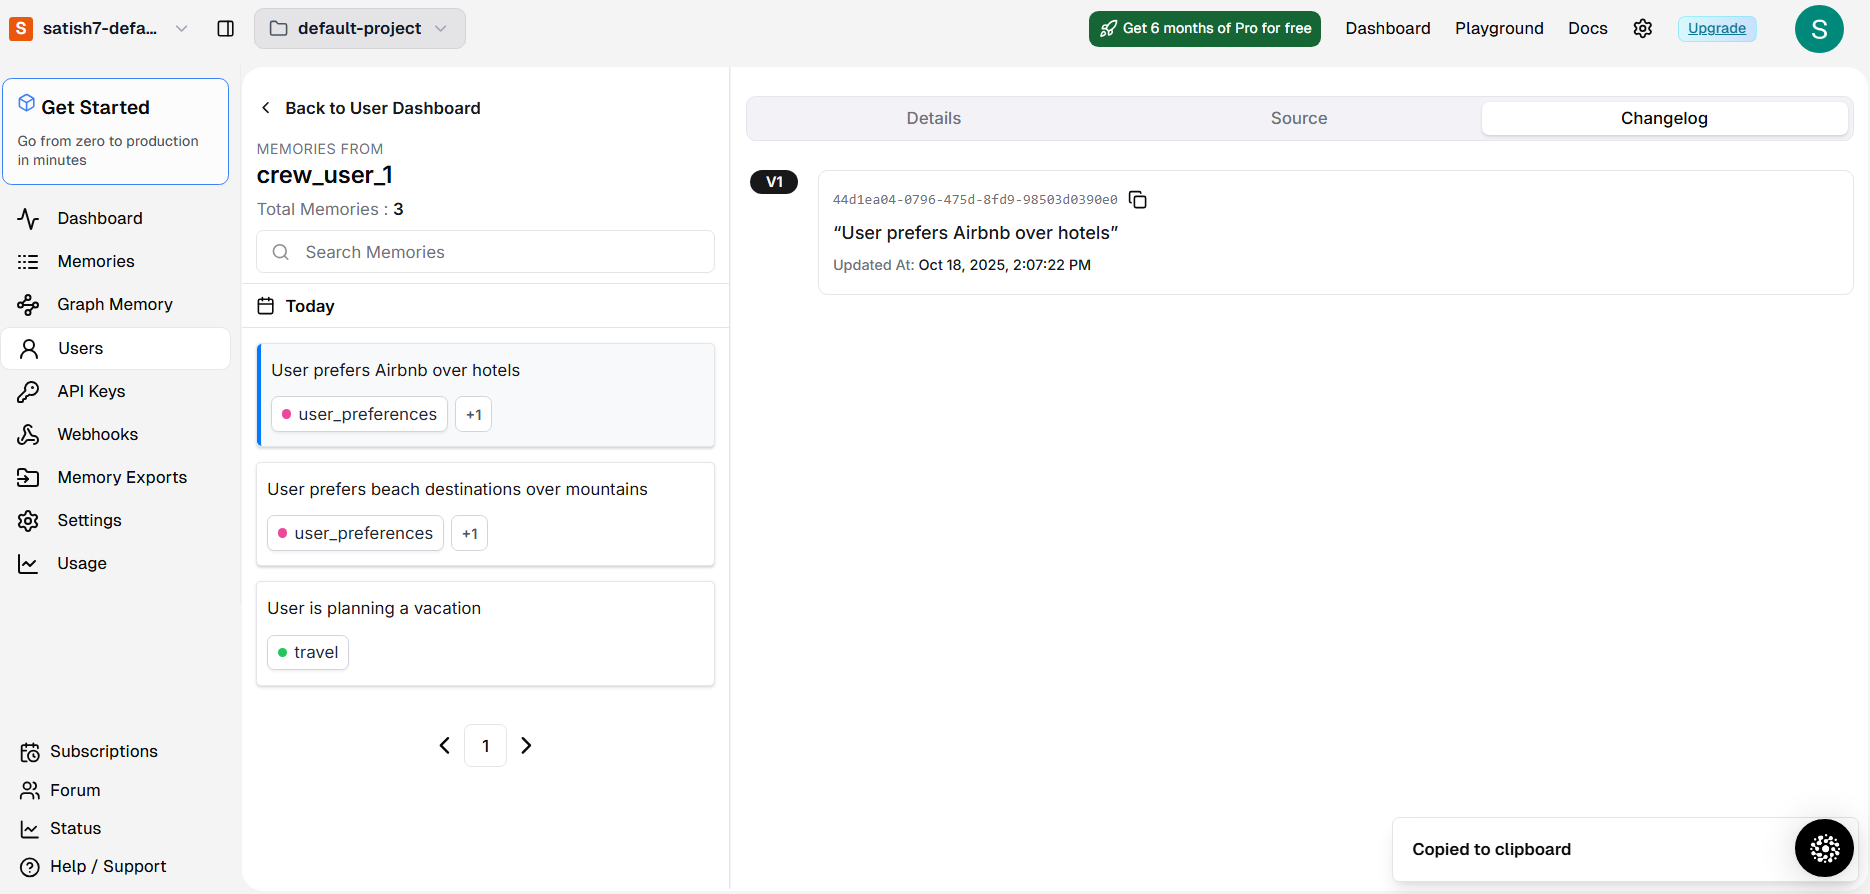 <br>

---
